In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

PROJECT_PATH = "/content/drive/MyDrive/ML_PROJECT/Fraud_Detection_System"
DATA_PATH = os.path.join(PROJECT_PATH, "creditcard.csv")

print("Project Path Exists:", os.path.exists(PROJECT_PATH))
print("Data File Exists:", os.path.exists(DATA_PATH))

Project Path Exists: True
Data File Exists: True


In [4]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [5]:
df = pd.read_csv(DATA_PATH)

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
# Check data types
print(df.dtypes)

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Check duplicates
print("\nDuplicate Rows:", df.duplicated().sum())

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing Values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Duplicate Rows: 1081


In [8]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,1.673327e-15,-1.247012e-15,8.190001e-16,1.207294e-15,4.887456e-15,1.437716e-15,-3.772171e-16,9.564149e-16,1.039917e-15,6.406204e-16,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
# Data Cleaning + Target Understanding

In [9]:

initial_shape = df.shape

df = df.drop_duplicates()

final_shape = df.shape

print("Before removing duplicates:", initial_shape)
print("After removing duplicates:", final_shape)
print("Rows removed:", initial_shape[0] - final_shape[0])

Before removing duplicates: (284807, 31)
After removing duplicates: (283726, 31)
Rows removed: 1081


In [10]:
# Class Distribution
class_counts = df['Class'].value_counts()

print(class_counts)
print("\nFraud Percentage:", (class_counts[1] / class_counts.sum()) * 100)

Class
0    283253
1       473
Name: count, dtype: int64

Fraud Percentage: 0.1667101358352777


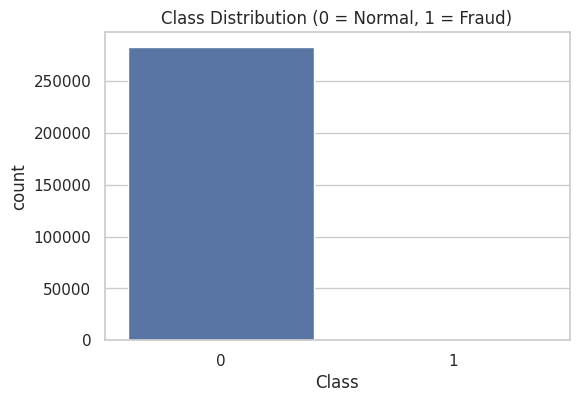

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0 = Normal, 1 = Fraud)")
plt.show()

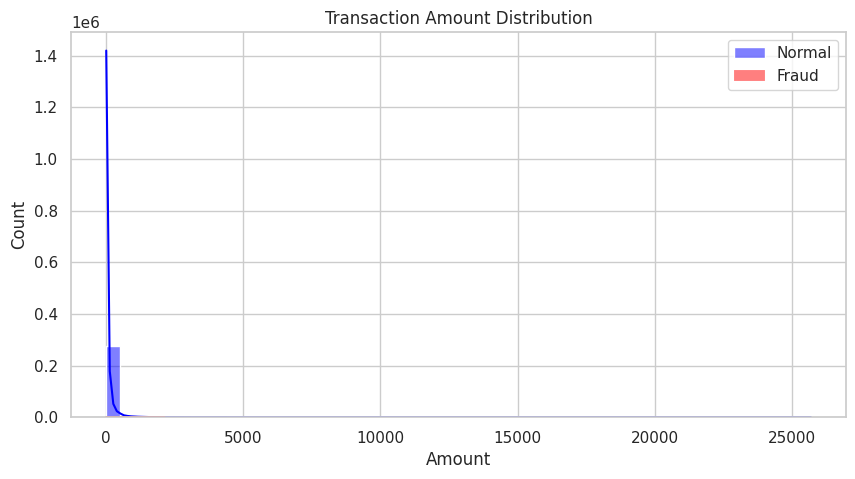

In [12]:
# Amount Distribution (Fraud vs Normal)
plt.figure(figsize=(10,5))

sns.histplot(df[df['Class'] == 0]['Amount'], bins=50, label='Normal', color='blue', kde=True)
sns.histplot(df[df['Class'] == 1]['Amount'], bins=50, label='Fraud', color='red', kde=True)

plt.legend()
plt.title("Transaction Amount Distribution")
plt.show()

Fraud is:

Rare (class imbalance problem)
Subtle (not just high-value transactions)

So:

Accuracy is useless
We will optimize for:
Recall (catch fraud)
Precision (avoid false alarms)

In [13]:
# Feature Engineering

In [14]:
df['Hour'] = (df['Time'] // 3600) % 24

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['Amount_Scaled'] = scaler.fit_transform(df[['Amount']])

In [16]:
df = df.drop(['Time', 'Amount'], axis=1)

In [17]:
print("Final Columns:\n", df.columns)
print("\nDataset Shape:", df.shape)
df.head()

Final Columns:
 Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Hour',
       'Amount_Scaled'],
      dtype='object')

Dataset Shape: (283726, 31)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class,Hour,Amount_Scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.0,0.244200
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,0.0,-0.342584
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,0.0,1.158900
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.0,0.139886
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.0,-0.073813


In [18]:
# Train/Test Split + Handling Imbalance

In [19]:
X = df.drop('Class', axis=1)
y = df['Class']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (226980, 30)
Test Shape: (56746, 30)


Since the dataset is highly imbalanced, I used stratified sampling to preserve class distribution across train and test sets, ensuring reliable model evaluation.

In [21]:
print("\nTrain Fraud %:", (y_train.sum() / len(y_train)) * 100)
print("Test Fraud %:", (y_test.sum() / len(y_test)) * 100)


Train Fraud %: 0.16653449643140364
Test Fraud %: 0.16741268107003138


In [22]:
# Baseline Model (Logistic Regression)

In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [24]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [25]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[56641    10]
 [   39    56]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.59      0.70        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.85     56746
weighted avg       1.00      1.00      1.00     56746



In [26]:
from sklearn.metrics import roc_auc_score

roc_score = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.9573324761303976


Although ROC-AUC is high, recall for fraud is only 59%, meaning the model misses a significant portion of fraudulent transactions. In financial systems, recall is prioritized to minimize fraud loss.

### Handle Imbalance

Strategy

We will:

1. Use class_weight='balanced' (fast & safe)
2. Later → SMOTE (advanced)

In [28]:
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')

model_balanced.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [29]:
# prediction

y_pred_bal = model_balanced.predict(X_test)
y_prob_bal = model_balanced.predict_proba(X_test)[:, 1]

In [30]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_bal))

print("\nClassification Report:\n", classification_report(y_test, y_pred_bal))

Confusion Matrix:
 [[55236  1415]
 [   12    83]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.97      0.99     56746



In [31]:
roc_score_bal = roc_auc_score(y_test, y_prob_bal)
print("ROC-AUC Score:", roc_score_bal)

ROC-AUC Score: 0.9655614385029669


Fraud Class Performance<br>
Recall: 0.87  (HUGE improvement)<br>
Precision: 0.06  (very poor)<br>
F1-score: 0.10

In [33]:
# Threshold Tuning

In [34]:
threshold = 0.3

y_pred_custom = (y_prob_bal >= threshold).astype(int)

In [35]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_custom))

print("\nClassification Report:\n", classification_report(y_test, y_pred_custom))

Confusion Matrix:
 [[53532  3119]
 [   12    83]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.94      0.97     56651
           1       0.03      0.87      0.05        95

    accuracy                           0.94     56746
   macro avg       0.51      0.91      0.51     56746
weighted avg       1.00      0.94      0.97     56746



In [37]:
threshold = 0.2

y_pred_custom = (y_prob_bal >= threshold).astype(int)

In [38]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_custom))

print("\nClassification Report:\n", classification_report(y_test, y_pred_custom))

Confusion Matrix:
 [[51548  5103]
 [   10    85]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.91      0.95     56651
           1       0.02      0.89      0.03        95

    accuracy                           0.91     56746
   macro avg       0.51      0.90      0.49     56746
weighted avg       1.00      0.91      0.95     56746



I selected threshold = 0.3 as it maintains high fraud detection (recall ~87%) while reducing false positives compared to more aggressive thresholds

| Model               | Status                  |
| ------------------- | ----------------------- |
| Logistic (baseline) | Misses fraud ❌          |
| Logistic (balanced) | Too many false alarms ❌ |


In [39]:
!pip install xgboost

In [40]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:40:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [41]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [42]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

Confusion Matrix:
 [[56610    41]
 [   19    76]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.65      0.80      0.72        95

    accuracy                           1.00     56746
   macro avg       0.82      0.90      0.86     56746
weighted avg       1.00      1.00      1.00     56746



In [43]:
roc_xgb = roc_auc_score(y_test, y_prob_xgb)
print("ROC-AUC Score:", roc_xgb)

ROC-AUC Score: 0.9724186594002615


| Model               | Precision | Recall   | Verdict                 |
| ------------------- | --------- | -------- | ----------------------- |
| Logistic (baseline) | 0.85      | 0.59     | Misses fraud ❌          |
| Logistic (balanced) | 0.06      | 0.87     | Too many false alarms ❌ |
| **XGBoost**         | **0.65**  | **0.80** | **Best balance ✅🔥**    |


I compared baseline and class-balanced models, then used XGBoost with class weighting. This significantly improved recall while controlling false positives, achieving a strong precision-recall balance.

In [44]:
# Feature Importance (Model Explainability)

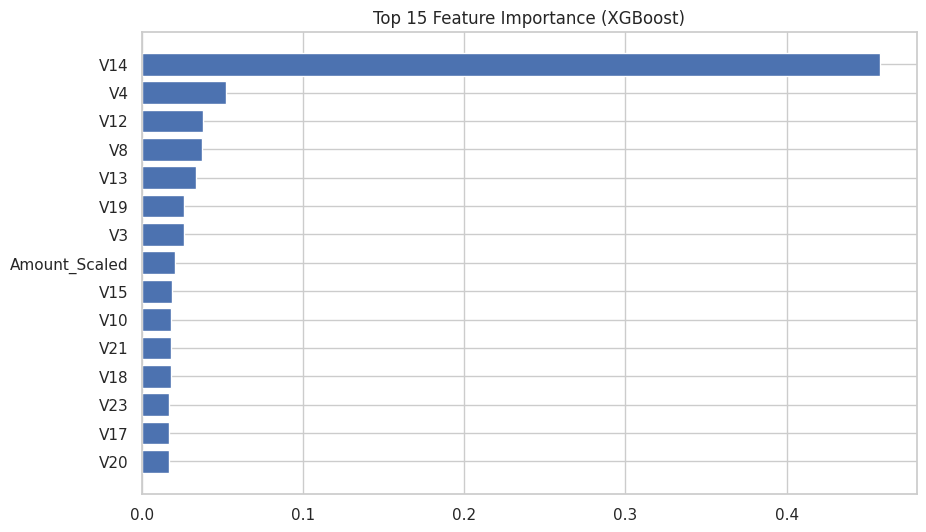

In [45]:
import matplotlib.pyplot as plt

importance = xgb_model.feature_importances_
features = X.columns

# Create DataFrame
feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(feat_imp['Feature'][:15], feat_imp['Importance'][:15])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importance (XGBoost)")
plt.show()

The model heavily relies on transformed behavioral features (V1–V28), especially V14, indicating that fraud detection depends more on transaction patterns rather than raw transaction amount

In [46]:
# SHAP (Explainability)

In [47]:
!pip install shap

In [48]:
import shap

explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

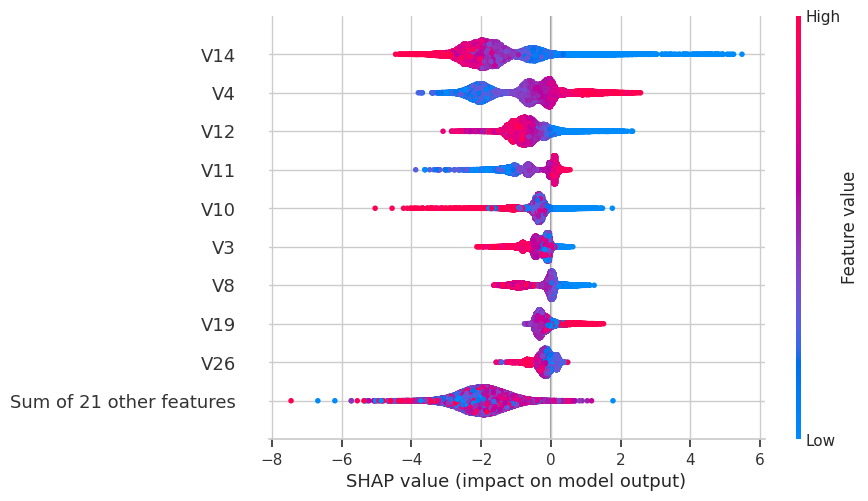

In [49]:
shap.plots.beeswarm(shap_values)

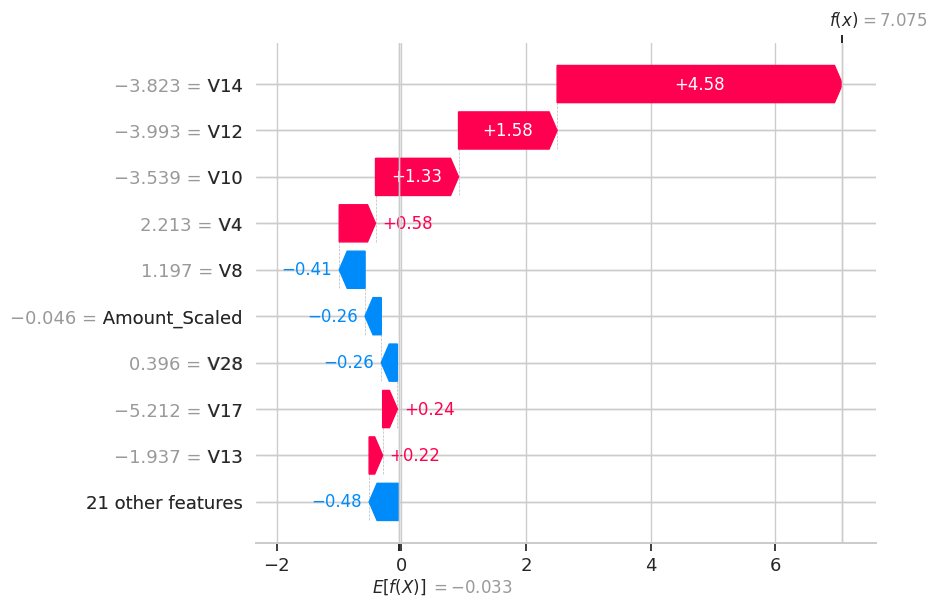

In [51]:
fraud_position = np.where(y_test.values == 1)[0][0]

shap.plots.waterfall(shap_values[fraud_position])

I used SHAP values to interpret model predictions, identifying key contributing features for fraud detection and ensuring model transparency required for financial systems.

## 📊 1. SHAP Summary Plot (Global Insight)

### ✅ What you observed:
- **V14 is dominant** (again confirmed 🔥)
- Followed by: **V4, V12, V11, V10**
- Strong spread → features have **real impact**

---

### 🧠 Interpretation

- 👉 Points on the **right** → push toward **fraud**
- 👉 Points on the **left** → push toward **normal**

**Color Meaning:**
- 🔴 High value  
- 🔵 Low value  

---

### 🔥 Key Insight

Certain ranges of **V14, V12, V10** strongly increase fraud probability.

**This means:**
- 👉 Fraud is driven by **specific hidden behavioral patterns**

---

## 📊 2. SHAP Waterfall Plot (Single Transaction)

This is where your project becomes **insane-level good**.

---

### 🔹 Prediction Breakdown

**Final prediction:**
- f(x) = 7.075 → HIGH FRAUD PROBABILITY
---

### 🔺 Features pushing toward FRAUD (RED)

- **V14 → +4.58 🚀 (huge impact)**
- V12 → +1.58  
- V10 → +1.33  
- V4 → +0.58  

👉 These features **strongly signal fraud**

---

### 🔻 Features pushing toward NORMAL (BLUE)

- V8 → -0.41  
- Amount_Scaled → -0.26  
- V28 → -0.26  

👉 These features **reduce fraud probability**

In [52]:
# Model Saving + Prediction Pipeline

import joblib
import os

MODEL_PATH = os.path.join(PROJECT_PATH, "xgb_fraud_model.pkl")

joblib.dump(xgb_model, MODEL_PATH)

print("Model saved at:", MODEL_PATH)

Model saved at: /content/drive/MyDrive/ML_PROJECT/Fraud_Detection_System/xgb_fraud_model.pkl


In [53]:
SCALER_PATH = os.path.join(PROJECT_PATH, "scaler.pkl")

joblib.dump(scaler, SCALER_PATH)

print("Scaler saved at:", SCALER_PATH)

Scaler saved at: /content/drive/MyDrive/ML_PROJECT/Fraud_Detection_System/scaler.pkl


In [57]:
def predict_transaction(input_data, model_path, scaler_path):
    import pandas as pd
    import joblib

    # Load model & scaler
    model = joblib.load(model_path)
    scaler = joblib.load(scaler_path)

    # Convert to DataFrame
    df_input = pd.DataFrame([input_data])

    # ❗ Remove target if present
    if 'Class' in df_input.columns:
        df_input = df_input.drop('Class', axis=1)

    # Feature engineering
    df_input['Hour'] = (df_input['Time'] // 3600) % 24
    df_input['Amount_Scaled'] = scaler.transform(df_input[['Amount']])

    # Drop raw columns
    df_input = df_input.drop(['Time', 'Amount'], axis=1)

    # 🔥 Ensure correct column order
    df_input = df_input[X_train.columns]

    # Prediction
    prob = model.predict_proba(df_input)[:, 1][0]
    pred = int(prob >= 0.5)

    return {
        "fraud_probability": prob,
        "prediction": pred
    }

In [58]:
sample = df.iloc[0].copy()
sample_input = sample.to_dict()

# Add required raw fields
sample_input['Time'] = 100000
sample_input['Amount'] = 150

result = predict_transaction(sample_input, MODEL_PATH, SCALER_PATH)

print(result)

{'fraud_probability': np.float32(0.0045015393), 'prediction': 0}
